# Load Iris Analysis Using Hierarchical Clustering (Agglomerative, Divisive, FCLuster and Dendrogram) with PCA and Scalar 

## Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.cluster import AgglomerativeClustering, BisectingKMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from scipy.cluster.hierarchy import linkage, dendrogram, fcluster

import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="joblib")

import os
os.environ["LOKY_MAX_CPU_COUNT"] = "1"

## Load dataset

In [2]:
iris = load_iris()

X = pd.DataFrame(
    iris.data,
    columns=iris.feature_names
)

print("Dataset Shape:", X.shape)
print("\nFirst 5 Records:")
X.head()

Dataset Shape: (150, 4)

First 5 Records:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


## Standardize features (Before clustering)

In [3]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## Agglomerative Clustering (Bottom-Up)

In [4]:
agg = AgglomerativeClustering(
    n_clusters=3,
    linkage="ward"
)

## Bisecting K-Means (Top-Down)

In [5]:
div = BisectingKMeans(
    n_clusters=3,
    random_state=42
)

## Linkage matrix

In [6]:
Z = linkage(
    X_scaled,
    method="ward"
)

## Cluster labels

In [7]:
agg_labels = agg.fit_predict(X_scaled)
div_labels = div.fit_predict(X_scaled)
dendro_labels = fcluster(Z, t=3, criterion="maxclust") # Extract 3 clusters from the dendrogram

X["Agglomerative_Cluster"] = agg_labels
X["Bisecting_Cluster"] = div_labels
X["Dendrogram_Cluster"] = dendro_labels

### Sample records

In [8]:
print("\nDataset with Cluster Labels:")
X.head()


Dataset with Cluster Labels:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),Agglomerative_Cluster,Bisecting_Cluster,Dendrogram_Cluster
0,5.1,3.5,1.4,0.2,1,0,1
1,4.9,3.0,1.4,0.2,1,0,1
2,4.7,3.2,1.3,0.2,1,0,1
3,4.6,3.1,1.5,0.2,1,0,1
4,5.0,3.6,1.4,0.2,1,0,1


### Cluster counts

In [9]:
print("\nAgglomerative Cluster Counts")

for cluster, count in X["Agglomerative_Cluster"].value_counts().sort_index().items():
    print(f"Cluster {cluster}: {count} samples")

print("\nBisecting K-Means Cluster Counts")

for cluster, count in X["Bisecting_Cluster"].value_counts().sort_index().items():
    print(f"Cluster {cluster}: {count} samples")

print("\nDendrogram Cluster Counts")

for cluster, count in X["Dendrogram_Cluster"].value_counts().sort_index().items():
    print(f"Cluster {cluster}: {count} samples")    


Agglomerative Cluster Counts
Cluster 0: 71 samples
Cluster 1: 49 samples
Cluster 2: 30 samples

Bisecting K-Means Cluster Counts
Cluster 0: 50 samples
Cluster 1: 56 samples
Cluster 2: 44 samples

Dendrogram Cluster Counts
Cluster 1: 49 samples
Cluster 2: 30 samples
Cluster 3: 71 samples


## Visualization

### Dendrogram

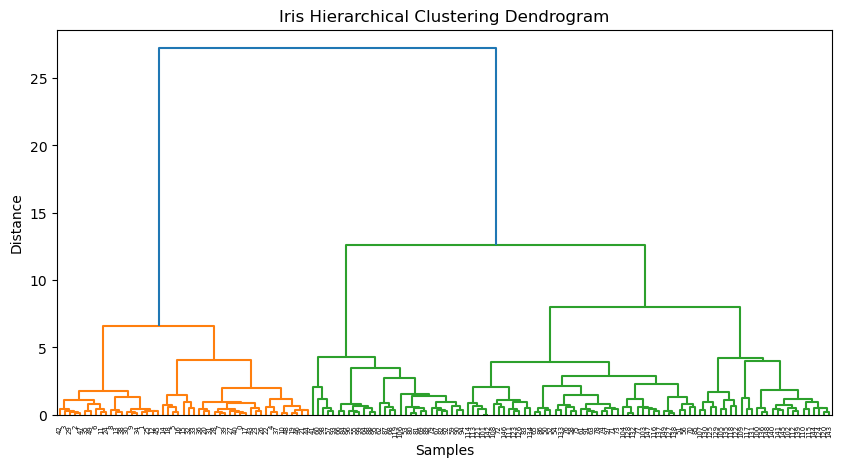

In [10]:
plt.figure(figsize=(10, 5))

dendrogram(Z)

plt.title("Iris Hierarchical Clustering Dendrogram")
plt.xlabel("Samples")
plt.ylabel("Distance")
plt.savefig("Iris Hierarchical Clustering Dendrogram.png",dpi=100)
plt.show()

In [11]:
# Reduce dimensions for visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

### Clustering methods

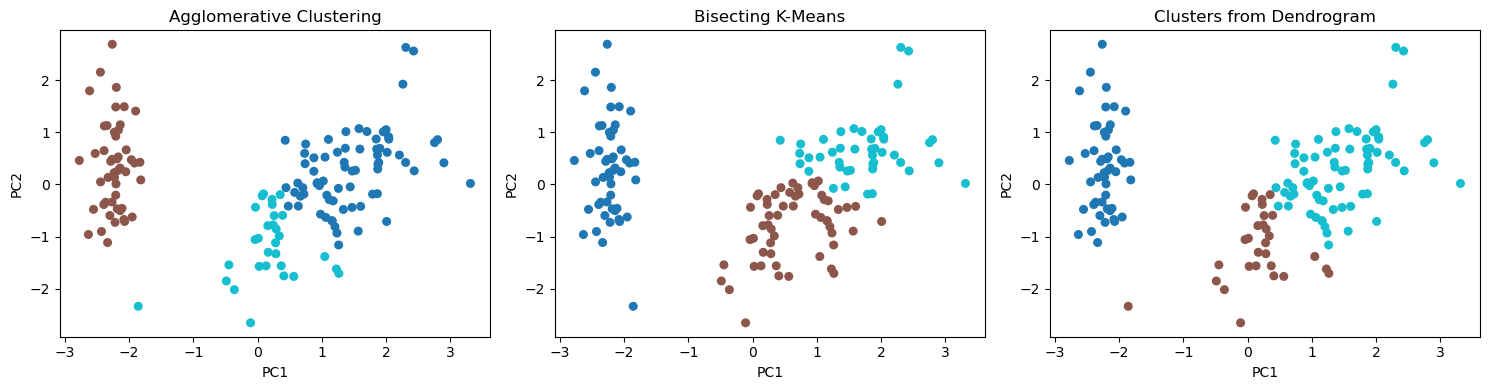

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))


axes[0].scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=agg_labels,
    cmap="tab10",
    s=30
)

axes[0].set_title("Agglomerative Clustering")
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")


axes[1].scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=div_labels,
    cmap="tab10",
    s=30
)

axes[1].set_title("Bisecting K-Means")
axes[1].set_xlabel("PC1")
axes[1].set_ylabel("PC2")


axes[2].scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=dendro_labels,
    cmap="tab10",
    s=30
)

axes[2].set_title("Clusters from Dendrogram")
axes[2].set_xlabel("PC1")
axes[2].set_ylabel("PC2")

plt.savefig("Iris Clustring Methods.png",dpi=100)
plt.tight_layout()
plt.show()